In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mssm.models import *
from mssmViz.plot import *
import matplotlib
import copy as copy
from matplotlib import font_manager
import dotenv
import os
dotenv.load_dotenv()

# Optionally load fonts (plots want "Source Sans 3")
font_path = os.getenv("font_path")
n_cores = int(os.getenv("n_cores"))

if font_path is not None:
    font_files = font_manager.findSystemFonts(fontpaths=font_path)
    for font_file in font_files:
        font_manager.fontManager.addfont(font_file)

# Some settings for plots
cmp = matplotlib.colormaps['RdYlBu_r']
plt.rcParams["font.family"] = "Source Sans 3"
plt.rcParams["font.weight"] = "semibold"
plt.rcParams["font.size"] = 8
plt.rcParams["axes.titlesize"] = 9.5
plt.rcParams["axes.labelsize"] = 8
plt.rcParams["xtick.labelsize"] = 8
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["legend.fontsize"] = 8
plt.rcParams["figure.titlesize"] = 11
math_font_size = 8
math_font = 'cm'

seed = 42*3
np_gen = np.random.default_rng(seed)

size_conv = 2.54
single_width = 6/size_conv
double_width = 12/size_conv
full_width = 19/size_conv

## HSMM of Energy Prices

In [ ]:
# Load data
energy_dat = pd.read_csv("./data/energy.csv")

# Create pseudo dat for latent process model
d_dat = pd.DataFrame({"pseudo": np.arange(1)})

# Setup hsmm via mssm
o_family = GAUMLSS()
d_family = GAMMALS()
n_S = 2 # Number of latent states
M = 1 # Number of observed signals
D = 100 # Max duration assumed for latent states
starts_with_first = True # First state starts with first observation?
links = []
obs_families = []
obs_formulas = []
d_families = []
d_formulas = []
pars = 0

for j in range(n_S):
    obs_families.append([])

    for m in range(M):
        obs_families[-1].append(o_family)
        # Model of mean of obs model in state j and of signal m
        obs_formulas.append(Formula(lhs("Price"), [i(),f(["EurDol"])], data=energy_dat))

        # Model of scale parameter of obs model in state j and of signal m is the same
        obs_formulas.append(Formula(lhs("Price"), [i(),f(["EurDol"])], data=energy_dat))

        links.extend(o_family.links)
        pars += 2

for j in range(n_S * (1 if starts_with_first else 2)):
    d_families.append(d_family)

    # Model of mean of dur model in state j
    d_formulas.append(Formula(lhs("pseudo"), [i()], data=d_dat))

    # Model of scale parameter of dur model in state j
    d_formulas.append(Formula(lhs("pseudo"), [i()], data=d_dat))

    links.extend(d_family.links)
    pars += 2

# State transition probabilities and initial state durations can be fixed
pi = np.array([1, 0])
T = np.array([[0, 1], [1,0]])

# Initialize Family
fam = HSMMFamily(
    pars,
    links,
    n_S,
    obs_fams=obs_families,
    d_fams=d_families,
    sid=np.array([0]),
    tid=None,
    T=T,
    pi=pi,
    D=D,
    M=M,
    starts_with_first=starts_with_first,
    ends_with_last=True,
    ends_in_last=False,
    n_cores=1,
)

energy_model = GSMM([*obs_formulas,*d_formulas],fam)
energy_model.fit(n_cores=n_cores*2,
                 method='qEFS',
                 sample_hessian=False,
                 structured_qefs=False,
                 global_opt_qefs=True)


Fitting - Conv.: 6.76e+01:   1%|          | 2/200 [07:26<13:05:20, 237.98s/it]

/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:1198: UserWarning: Setting ``response_scale=True`` is usually only appropriate for GAMMs or GAMMLSS.
  warnings.warn(
/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:1198: UserWarning: Setting ``response_scale=True`` is usually only appropriate for GAMMs or GAMMLSS.
  warnings.warn(


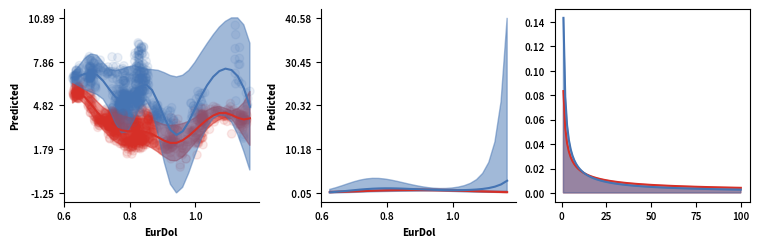

In [ ]:
fig = plt.figure(figsize=(full_width,single_width),layout='constrained')
axs = fig.subplots(1,3,gridspec_kw=dict(wspace=0.01,hspace=0.1))
viterbi = fam.decode_viterbi(energy_model.coef,energy_model.coef_split_idx,
                             energy_model.get_ys(),energy_model.get_mmat())

axs[0].scatter(energy_dat["EurDol"],energy_dat["Price"],
               c=[cmp(0.9) if s == 0 else cmp(0.1) for s in viterbi[0][1]],alpha=0.1)

pred_dat = pd.DataFrame({"EurDol":np.linspace(energy_dat["EurDol"].min(),
                                              energy_dat["EurDol"].max(),30)})

plot_fitted(pred_dat,["EurDol"],energy_model,ax=axs[0],response_scale=False,col=0.9,dist_par=0)
plot_fitted(pred_dat,["EurDol"],energy_model,ax=axs[0],response_scale=False,col=0.1,dist_par=2)

plot_fitted(pred_dat,["EurDol"],energy_model,ax=axs[1],response_scale=True,col=0.9,dist_par=1)
plot_fitted(pred_dat,["EurDol"],energy_model,ax=axs[1],response_scale=True,col=0.1,dist_par=3)

d_probs = fam.compute_od_probs(energy_model.coef,energy_model.coef_split_idx,
                               energy_model.get_ys(),energy_model.get_mmat(),
                               log=False)[0][1]
for si in range(2):
    
    pmf = d_probs[:,si]
    support = np.linspace(1,D,pmf.shape[0])

    axs[2].fill([*support,*np.flip(support)],
                [*pmf,*np.zeros_like(pmf)],
                color=(cmp(0.9) if si == 0 else cmp(0.1)),
                alpha=0.5)
    axs[2].plot(support,pmf,color=(cmp(0.9) if si == 0 else cmp(0.1)))
